# Imports

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pf
import sys
import os
import h5py
from scipy import constants
from numpy import unravel_index
from scipy.optimize import curve_fit
from h5Manager import ExpViewer

def read_RID(rid, exp_name="ClockRamseyPhase2D"):
    with h5py.File(f'Data/0000{rid}-{exp_name}_exp.h5', 'r') as f:
        x = f['datasets']['detection.images'][:]
    return x

# decaying sine
def sineFit(x, A, phi, y0):
    return (A*np.sin(x+phi)+y0)

def batman(x, n, P0, C):
    return n/np.sqrt(1-((P0-x)/(C/2))**2)

def gausFit(x, A, s):
    return (A*np.exp(-x**2/(2*s**2)))

# Ramsey Phase Scan Experiment

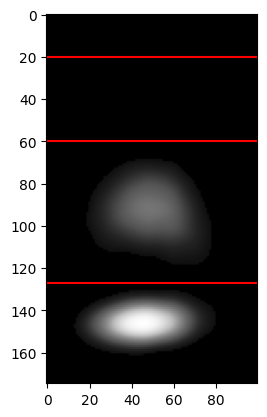

In [7]:
# extract and process images

direc = "C:/Users/ggpan/OneDrive - Stanford/Research/manuscripts/DFSequentialPaper/ThreePhotonSimulations/Data/"
RID = 75268

exp = ExpViewer(RID, dir=direc)
ims = np.array(exp.images)

#plt.imshow(exp.images[5])  # check that image looks good
#plt.show()

ims = ims[:,100:275, 50:150]
threshold = 20
ims = np.where(ims > threshold, ims, 0)

bins = (20, 60, 127,280)
for val in bins:
    plt.axhline(val, color='red')
plt.imshow(1-ims[2],cmap='Greys')  # check that processed image looks good
plt.show()

In [8]:
x1 = [np.sum(ims[i,bins[1]:bins[2],:])/np.sum(ims[i,bins[1]:bins[3],:]) for i in range(len(ims))]
x2 = [np.sum(ims[i,bins[2]:bins[3],:])/np.sum(ims[i,bins[1]:bins[3],:]) for i in range(len(ims))]

nrepeats=5
npoints=100
p = np.linspace(0,2*np.pi,int(npoints/nrepeats))

x1avg = np.mean(np.reshape(x1,[int(npoints/nrepeats),nrepeats]),axis=1)
x1err= np.std(np.reshape(x1,[int(npoints/nrepeats),nrepeats]),axis=1)
x2avg = np.mean(np.reshape(x2,[int(npoints/nrepeats),nrepeats]),axis=1)
x2err= np.std(np.reshape(x2,[int(npoints/nrepeats),nrepeats]),axis=1)

[0.7435106367387153, 0.0401051304043997]
[0.8, inf]
0.8552808870821497


C:\Users\ggpan\AppData\Local\Temp\ipykernel_16624\767921122.py:22: RuntimeWarning: invalid value encountered in sqrt
  return n/np.sqrt(1-((P0-x)/(C/2))**2)
c:\Users\ggpan\anaconda3\Lib\site-packages\scipy\optimize\_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


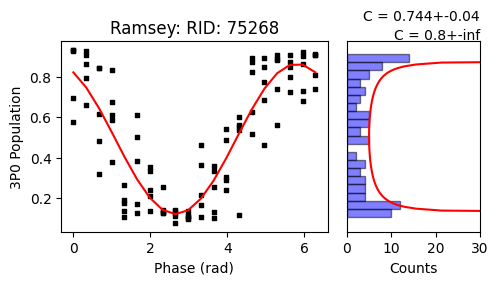

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]}, figsize=(5, 3))
p2 = [item for item in p for _ in range(nrepeats)]
# Plot scatter points and sinusoidal fit on the left
ax1.scatter(p2,x2, c='black', marker='s',s=10)

popt, pcov = curve_fit(sineFit, p2, x2, p0=[0.5,3.14, 0.5], maxfev=20000)
print([2*popt[0],2*np.sqrt(np.diag(pcov))[0]])
ax1.plot(p, sineFit(p, *popt), c='r')
ax1.set_xlabel('Phase (rad)')
ax1.set_ylabel('3P0 Population')
ax1.set_title(f"Ramsey: RID: {RID}")

ax2.text(1, 1.11, f"C = {2*np.round(popt[0], 3)}+-{2*np.round(np.sqrt(np.diag(pcov))[0], 3)}", transform=ax2.transAxes, ha="right", color='black')

# Plot the histogram on the right with the correct orientation
counts, bins, _ = ax2.hist(x2, bins=20, alpha=0.5, color='blue', orientation='horizontal', edgecolor='black')
bins = np.array(bins)
bins = (bins[1:] + bins[:-1])/2

popt1,pcov1 = curve_fit(batman,bins,counts, p0=[5,0.5, 0.8], maxfev=20000)
ax2.plot(batman(np.linspace(0,1,100),*popt1),np.linspace(0,1,100), color='red' )
print([popt1[-1],np.sqrt(np.diag(pcov1))[-1]])
ax2.set_ylim(0,1)
ax2.set_xlim(0,30)

# Label the histogram
ax2.set_xlabel('Counts')
ax2.set_yticks([])

ax2.text(1, 1.01, f"C = {np.round(popt1[-1], 3)}+-{np.round(np.sqrt(np.diag(pcov1))[-1], 3)}", transform=ax2.transAxes, ha="right", color='black')


print(max(x2)-min(x2))


plt.tight_layout()
plt.show()



[-0.10220912444434109, 0.012283103669639167]


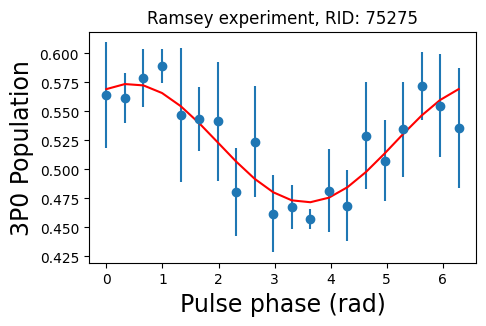

In [201]:
plt.figure(figsize=(5,3))
plt.errorbar(p,x2avg,yerr=x2err, fmt='o')


popt, pcov = curve_fit(sineFit, p, x2avg, p0=[0.5,3.14, 0.5], maxfev=20000)
plt.plot(p, sineFit(p, *popt), c='r')
print([2*popt[0],2*np.sqrt(np.diag(pcov))[0]])

plt.xlabel("Pulse phase (rad)", fontsize=17)
plt.ylabel("3P0 Population", fontsize=17)
plt.title(f"Ramsey experiment, RID: {RID}")
plt.show()

[0.19930487498560598, 0.004412338858381396]


C:\Users\ggpan\AppData\Local\Temp\ipykernel_5584\3050089726.py:21: RuntimeWarning: invalid value encountered in sqrt
  return n/np.sqrt(1-((P0-x)/(C/2))**2)


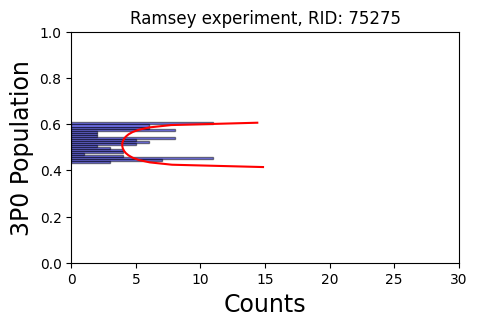

In [202]:
plt.figure(figsize=(5,3))

# Plot the histogram on the right with the correct orientation
counts, bins, _ = plt.hist(x2, bins=20, alpha=0.5, color='blue',  edgecolor='black', orientation='horizontal')
bins = np.array(bins)
bins = (bins[1:] + bins[:-1])/2

popt1,pcov1 = curve_fit(batman,bins,counts, p0=[5,0.5, 0.9], maxfev=20000)
plt.plot(batman(np.linspace(0,1,100),*popt1),np.linspace(0,1,100), color='red' )
print([popt1[-1],np.sqrt(np.diag(pcov))[-1]])
plt.xlim(0,30)
plt.ylim(0,1)
plt.xlabel("Counts", fontsize=17)
plt.ylabel("3P0 Population", fontsize=17)
plt.title(f"Ramsey experiment, RID: {RID}")
plt.show()


## Contrast Decay

In [255]:
times = np.array([0,0.1,0.25,0.5,1,1.5,2,3,4])
c1 = np.array([.744,.708,0.664,0.673,0.554,0.461,0.354,0.202,0.1])
c2 = np.array([.798,.788,.819,0.775,0.723,0.579,0.478,0.303,0.196])
c3 = np.array([0.855,0.842,.817,0.778,0.696,0.612,0.509,0.308,0.175])
c2err=np.array([ 0.0038892809062378276,0.006538270387600346, 0.03002696925588647, 0.06936591821747878, 0.04700591966566616,0.0085083362973563, 0.0031961654695890525 ,0.012031700243072296,0.03268534210654094 ])

3.0508568935507854


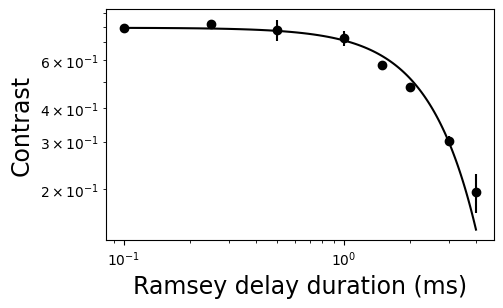

In [261]:
plt.figure(figsize=(5,3))

popt, pcov = curve_fit(gausFit, times, c2, p0=[1,1.500], maxfev=20000)
#popt1, pcov1 = curve_fit(sineFit, f, x2, p0=[0.5,5, 0, 0.5], maxfev=20000)
plt.plot(np.linspace(times[1],times[-1],100), gausFit(np.linspace(times[1],times[-1],100), *popt), c='black')
print(popt[-1]*np.sqrt(2))
plt.errorbar(times, c2, yerr=c2err, c='black', fmt='o')

plt.xlabel("Ramsey delay duration (ms)", fontsize=17)
plt.ylabel("Contrast", fontsize=17)
plt.xscale('log')
plt.yscale('log')
plt.show()

# Ramsey contrast decay

### Test bins

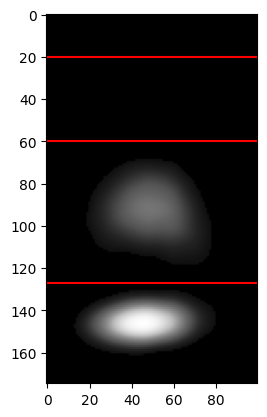

In [74]:
direc = "C:/Users/ggpan/OneDrive - Stanford/Research/manuscripts/DFSequentialPaper/ThreePhotonSimulations/Data/"
RID = 75268

exp = ExpViewer(RID, dir=direc)
ims = np.array(exp.images)

ims = ims[:,100:275, 50:150]
threshold = 20
ims = np.where(ims > threshold, ims, 0)

port_bins = (20, 60, 127,280)
for val in bins:
    plt.axhline(val, color='red')
plt.imshow(1-ims[2],cmap='Greys')  # check that processed image looks good
plt.show()

### Definition

In [128]:
nrepeats=5
npoints=100

def analyze_rid(rid, plot_data=False):

    exp = ExpViewer(rid, dir=direc)
    ims = np.array(exp.images)

    ims = ims[:,100:275, 50:150]
    threshold = 20
    ims = np.where(ims > threshold, ims, 0)

    x1 = [np.sum(ims[i,port_bins[1]:port_bins[2],:])/np.sum(ims[i,port_bins[1]:port_bins[3],:]) for i in range(len(ims))]
    x2 = [np.sum(ims[i,port_bins[2]:port_bins[3],:])/np.sum(ims[i,port_bins[1]:port_bins[3],:]) for i in range(len(ims))]

    p = np.linspace(0,2*np.pi,int(npoints/nrepeats))

    x1avg = np.mean(np.reshape(x1,[int(npoints/nrepeats),nrepeats]),axis=1)
    x1err= np.std(np.reshape(x1,[int(npoints/nrepeats),nrepeats]),axis=1)
    x2avg = np.mean(np.reshape(x2,[int(npoints/nrepeats),nrepeats]),axis=1)
    x2err= np.std(np.reshape(x2,[int(npoints/nrepeats),nrepeats]),axis=1)

    p2 = [item for item in p for _ in range(nrepeats)]
    popt, pcov = curve_fit(sineFit, p2, x2, p0=[0.5,3.14, 0.5], maxfev=20000)

    counts, bins = np.histogram(x2, bins=10)
    bins = np.array(bins)
    bins = (bins[1:] + bins[:-1])/2

    popt1,pcov1 = curve_fit(batman,bins,counts, p0=[5,0.5, 0.8], maxfev=20000)

    if plot_data:
        fig, (ax1, ax2) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]}, figsize=(5, 3))
        
        # Plot scatter points and sinusoidal fit on the left
        ax1.scatter(p2,x2, c='black', marker='s',s=10)

        
        ax1.plot(p, sineFit(p, *popt), c='r')
        ax1.set_xlabel('Phase (rad)')
        ax1.set_ylabel('3P0 Population')
        ax1.set_title(f"Ramsey: RID: {RID}")
        ax1.set_ylim(0,1)

        # Plot the histogram on the right with the correct orientation
        counts, bins, _ = ax2.hist(x2, bins=10, alpha=0.5, color='blue', orientation='horizontal', edgecolor='black')
        bins = np.array(bins)
        bins = (bins[1:] + bins[:-1])/2
        ax2.plot(batman(np.linspace(0,1,100),*popt1),np.linspace(0,1,100), color='red' )
        ax2.set_ylim(0,1)
        ax2.set_xlim(0,30)
        # Label the histogram
        ax2.set_xlabel('Counts')
        ax2.set_yticks([])
        plt.tight_layout()
        plt.show()
    
    return {
        "sine_contrast": np.array([2*np.abs(popt[0]),2*np.sqrt(np.diag(pcov))[0]]),
        "batman_contrast": np.array([np.abs(popt1[-1]),np.sqrt(np.diag(pcov1))[-1]]),
        "peak_contrast": np.array([max(x2)-min(x2),0.0])
    }

### Results

In [165]:
RID_list=[75268,75267,75269,75270,75271,75272,75273,75274,75275]
times = np.array([0,0.1,0.25,0.5,1,1.5,2,3,4])+0.001

C:\Users\ggpan\AppData\Local\Temp\ipykernel_30704\3050089726.py:21: RuntimeWarning: invalid value encountered in sqrt
  return n/np.sqrt(1-((P0-x)/(C/2))**2)


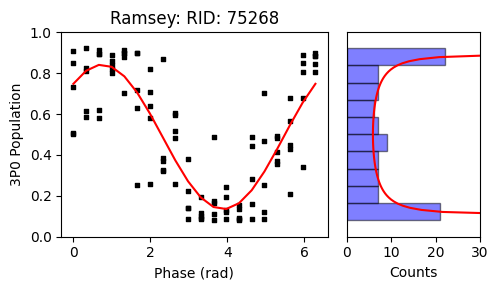

0.7076339915370208

In [166]:
results = analyze_rid(RID_list[1],plot_data=True)
results['sine_contrast'][0]

In [167]:
sine_contrast_list = []
batman_contrast_list = []
peak_contrast_list = []

sine_contrast_err_list = []
batman_contrast_err_list = []
peak_contrast_err_list = []

for rid in RID_list:
    res = analyze_rid(rid)
    
    sine_contrast_list.append(res['sine_contrast'][0])
    batman_contrast_list.append(res['batman_contrast'][0])
    peak_contrast_list.append(res['peak_contrast'][0])

    sine_contrast_err_list.append(res['sine_contrast'][1])
    batman_contrast_err_list.append(res['batman_contrast'][1])
    peak_contrast_err_list.append(res['peak_contrast'][1])

C:\Users\ggpan\AppData\Local\Temp\ipykernel_30704\3050089726.py:21: RuntimeWarning: invalid value encountered in sqrt
  return n/np.sqrt(1-((P0-x)/(C/2))**2)


In [168]:
batman_contrast_list

[0.7983759565227362,
 0.7884427248869254,
 0.8188602605981465,
 0.7757009482737951,
 0.723398077270601,
 0.579485271309191,
 0.47839434185398005,
 0.3033086352682952,
 0.19645502910215684]

3.0536532124124625
2.5531499316295525


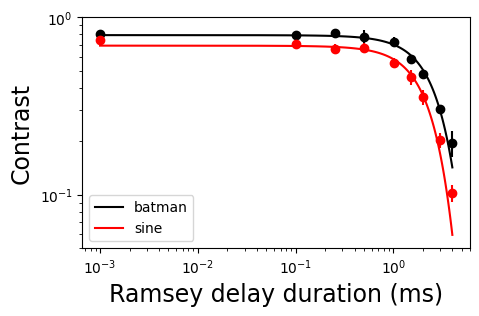

In [171]:
plt.figure(figsize=(5,3))
popt, pcov = curve_fit(gausFit, times, batman_contrast_list, p0=[1,1.500], maxfev=20000)
#popt1, pcov1 = curve_fit(sineFit, f, x2, p0=[0.5,5, 0, 0.5], maxfev=20000)
plt.plot(np.linspace(times[0],times[-1],100), gausFit(np.linspace(times[1],times[-1],100), *popt), c='black',label='batman')
print(popt[-1]*np.sqrt(2))
plt.errorbar(times, batman_contrast_list, yerr=batman_contrast_err_list, c='black',fmt='o')

popt, pcov = curve_fit(gausFit, times, sine_contrast_list, p0=[1,1.500], maxfev=20000)
#popt1, pcov1 = curve_fit(sineFit, f, x2, p0=[0.5,5, 0, 0.5], maxfev=20000)
plt.plot(np.linspace(times[0],times[-1],100), gausFit(np.linspace(times[1],times[-1],100), *popt), c='red',label='sine')
print(popt[-1]*np.sqrt(2))
plt.errorbar(times, sine_contrast_list, yerr=sine_contrast_err_list, c='red',fmt='o')

plt.legend()
plt.xlabel("Ramsey delay duration (ms)", fontsize=17)
plt.ylabel("Contrast", fontsize=17)
plt.ylim(0.05,1)
plt.xscale('log')
plt.yscale('log')
plt.show()

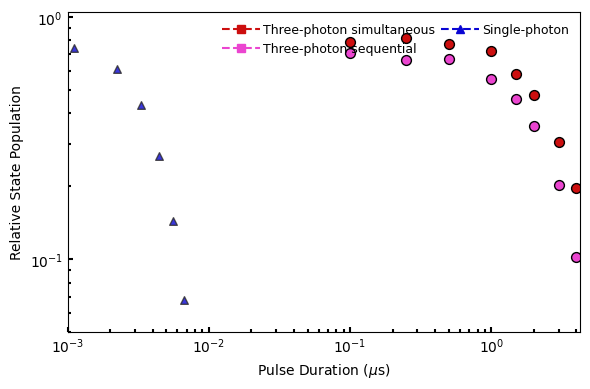

In [176]:
# --- PLOTS PARAMS -------------
update_2_2 = True
color_3v = "#CC0F0F"
color_1v = "#0905D3"
color_3v2 = "#eb45d0" 

assert(np.all(data_ro1[:,0] == data_ro2[:,0])) # make sure time axes are the same
t_data3v = times
t_data1v = np.linspace(0,0.01,10)
contrast_3v_simul = batman_contrast_list
contrast_3v_seq = sine_contrast_list
contrast_1v = 0.8*np.exp(-(t_data1v)**2/(2*0.003**2))


# --- Plotting ---
plt.rcParams.update({'font.size': 10, 'font.family': 'sans-serif'})
fig, ax = plt.subplots(figsize=(6, 4))



# 1. Plot  States 
ax.scatter(t_data, contrast_3v_simul, s=50, marker='o', ec='k', color=color_3v)
ax.scatter(t_data, contrast_3v_seq, s=50, marker='o', ec='k', color=color_3v2)
ax.scatter(t_data1v, contrast_1v, s=30, marker='^', ec="#2c2a2a", color=color_1v,alpha=0.8)


# # generating legend labels
ax.plot([],[], marker='s', linestyle='--', label=r'Three-photon simultaneous',color=color_3v)
ax.plot([],[], marker='s', linestyle='--', label=r'Three-photon sequential',color=color_3v2)
ax.plot([],[], marker='^', linestyle='--', label=r'Single-photon',color=color_1v)

# # ax.scatter(t_data, pop_3P1_data, '^', mc='k', color=color_3P1, alpha=0.35, markersize=4)

# # Formatting Main Axes
ax.set_xlabel(r'Pulse Duration ($\mu$s)')
ax.set_ylabel('Relative State Population')
ax.set_xlim(0.001, max(t_data) + 0.25)
ax.set_ylim(0.05, 1.05)
# ax.grid(True, which="major", ls="--", alpha=0.3)

ax.set_xscale('log')
ax.set_yscale('log')


# 
ax.legend(loc='upper right', fontsize=9, frameon=False, ncol=2,columnspacing=0.5,handlelength=3, handletextpad=0.25)

ax.tick_params(axis='both', direction="in", which='both', width=1.5)
plt.tight_layout()
plt.show()

# if update_2_2:
#     fig.savefig("Figures/fig2_2.pdf", dpi=300, bbox_inches="tight", facecolor="white")  # save for figure resolution
#     fig.savefig("Figures/fig2_2.png", dpi=150, bbox_inches="tight")  # save for previewing